# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

# plt.rcParams["figure.figsize"]=4,4
plt.rcParams["figure.dpi"]=150
# plt.rcParams["savefig.dpi"]=300
# plt.rcParams["font.family"] = "Arial"

warnings.filterwarnings("ignore")
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# - dirs 
from ciim.src.common import plots_dir, save_dir,cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major

from ciim.src.tf_activity.helper import retrieve_sig_net, get_consensus_net, retrieve_adata_bulk, retrieve_feature_data, retrieve_net, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_stats_features

from ciim.src.tf_activity.plots import plot_net_nx, plot_sig_tfs_stats

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df

# Bulk main

## Heatmap of sig TFs across cell types and cohorts

In [10]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'
stats_all = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy')

In [11]:
# - add sig signs
stats_sig = retrieve_sig_stats(type)
tuple_index = stats_sig.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all = stats_all.reset_index()[['tf', 'cell_type', 'dataset', 'slope', 'is_significant']].drop_duplicates()

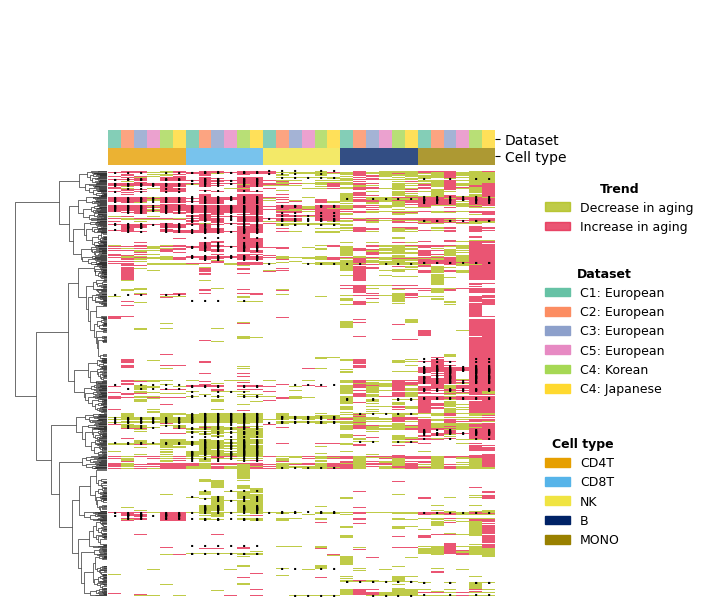

In [14]:
from ciim.src.tf_activity.plots import plot_overall_heatmap


stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Dataset'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Sig TFs counts

Text(0.5, 1.0, 'Aging TFs')

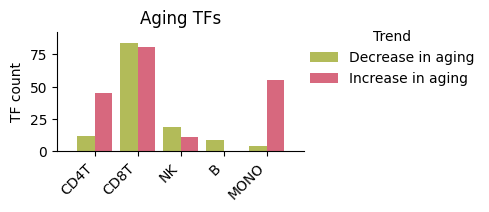

In [15]:

stats = retrieve_sig_stats(type='bulk', filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
# plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
plot_sig_tfs_stats(stats, figsize=(5, 2), palette=palette_trend_2)
plt.title(f'Aging TFs')

## Intersection of races

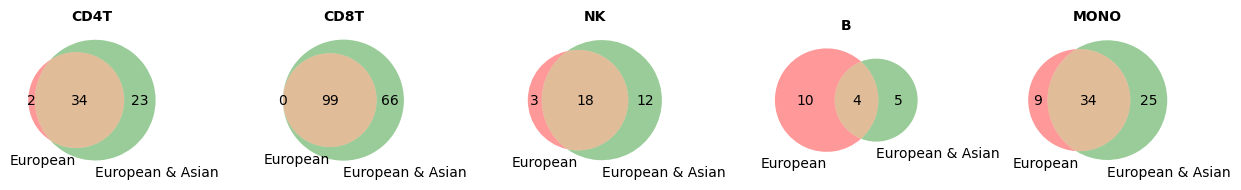

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

type = 'bulk'
# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, race='european')
stats_a = retrieve_sig_stats(type, race='both')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2.5 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    v = venn2([set_e, set_a], set_labels=('European', 'European & Asian'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Identify sig networks

In [26]:
retrieve_sig_stats(type, feature_type='gene_expression', race='both', filter_inconsistent=True, cell_type=None)

         target   p_value     slope  p_value_adj condition          dataset  \
0         ISG15  0.652388 -0.014399     0.739193   healthy            data1   
1      TNFRSF18  0.012059  0.080125     0.024675   healthy            data1   
2       TNFRSF4  0.017463  0.075873     0.034649   healthy            data1   
6         RPL22  0.000016 -0.137412     0.000063   healthy            data1   
10         ENO1  0.002137  0.097924     0.005130   healthy            data1   
...         ...       ...       ...          ...       ...              ...   
60920     ZNRF2  0.000019  0.345012     0.000117   healthy  data13_Japanese   
60921   ZSCAN18  0.000046 -0.329597     0.000238   healthy  data13_Japanese   
60923    ZSCAN9  0.000135  0.309652     0.000555   healthy  data13_Japanese   
60926    ZSWIM8  0.002612  0.246527     0.006077   healthy  data13_Japanese   
73230      ENHO  0.000009  0.337384     0.000895   healthy    data13_Korean   

      cell_type  slope_condition  ctrl        meta_

NameError: name 'aa' is not defined

In [20]:
from ciim.src.tf_activity.helper import determine_sig_network

type = 'bulk'

if True:
    determine_sig_network(type, min_degree=3)

Empty DataFrame
Columns: [target, p_value, slope, p_value_adj, condition, dataset, cell_type, slope_condition, ctrl, meta_p, meta_p_adj, neg_log10_adj_pval, trend, race]
Index: []
No target for CD4T  skipping it
No target for CD8T  skipping it
No target for NK  skipping it
No target for B  skipping it
No target for MONO  skipping it


ValueError: No objects to concatenate

In [19]:
from ciim.src.tf_activity.helper import retrieve_sig_net
cell_type = 'CD8T'
type = 'bulk'
race = 'both'
tfs = ['JUND', 'TCF7', 'MYC', 'BACH2']

sig_net = retrieve_sig_net(type, race, cell_type)
sig_net['sign'] = np.sign(sig_net['weight'])
sig_net.shape

(23779, 13)

### Network topology

In [20]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'{save_dir}/sig_nets/sig_nets_{type}_{race}.csv')

In [21]:
# nets['cell_type'].unique()

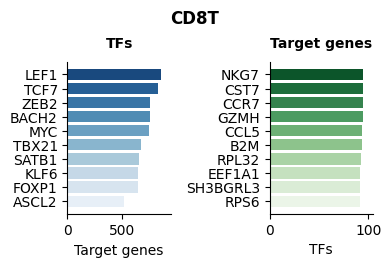

In [22]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

## Interaction of aging TFs between cell types

### T cells

In [27]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

type = 'bulk'
stats_sig = retrieve_sig_stats(type=type).drop_duplicates(subset=['cell_type', 'tf'])
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

['CD8T', 'MONO', 'CD4T', 'NK', 'B']


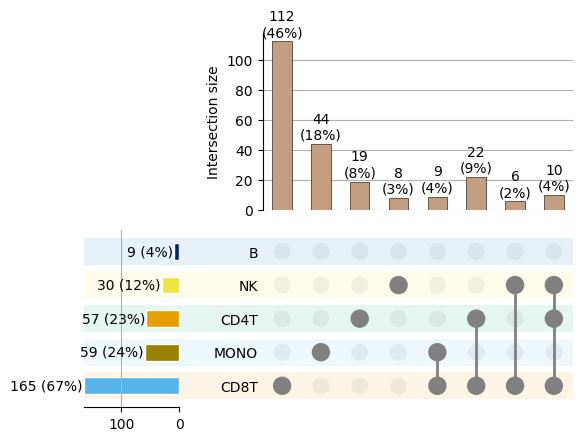

In [28]:
aa = plot_interactions(interaction_main_df, min_subset_size=5, min_degree=1, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activity/interactions.png', dpi=300)
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

10


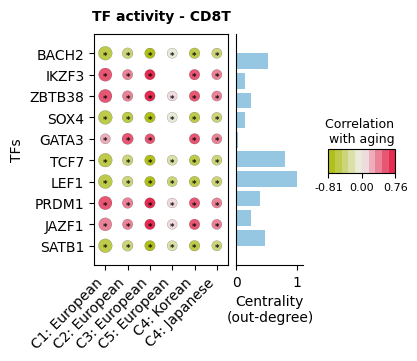

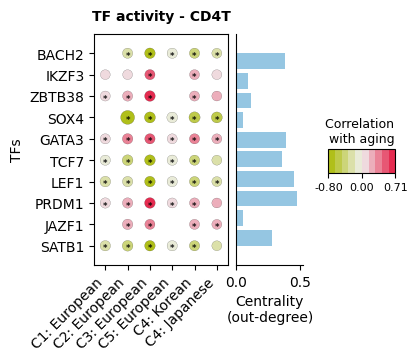

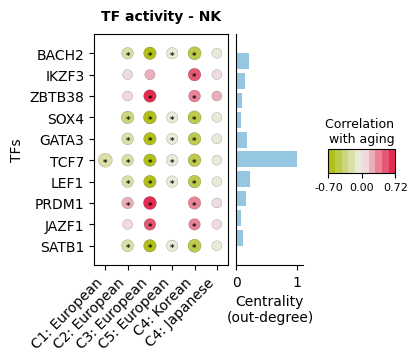

In [30]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, race='both', filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

### Shared sig TFs between CD8T and CD4T

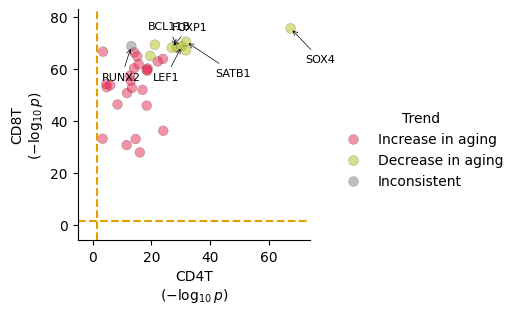

In [31]:
from ciim.src.tf_activity.plots import plot_joint_scatter

ttypes = ['CD8T', 'CD4T']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(features)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

## GSEA

In [33]:
from ciim.src.utils.util import pathway_analysis_wrapper
type = 'bulk'
feature_type = 'tf_activity'
race = 'both'
pathway_scores_store = []

stats_sig = retrieve_sig_stats(type, race=race)

pathway_scores = pathway_analysis_wrapper(stats_sig)
pathway_scores['race'] = race
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])


(6, 10)
(3, 10)
(7, 10)
(2, 10)
(1, 10)
(10, 10)
(2, 10)
(2, 10)


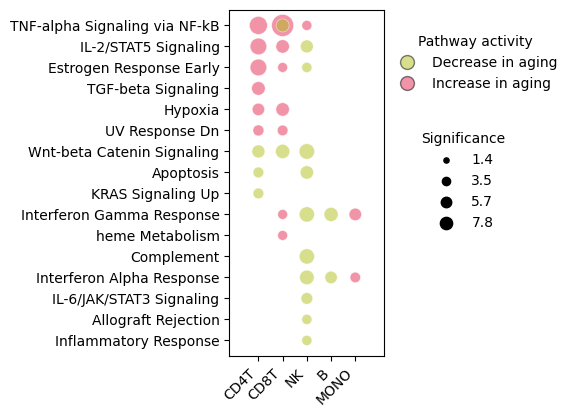

In [37]:
from ciim.src.tf_activity.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, ax = plt.subplots(1, 1, figsize=(2, 4.5), sharey=True, sharex=True)

pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
if i == len(races)-1:
    show_color_legend = True
    show_size_legend = True
else:
    show_color_legend = False
    show_size_legend = False
dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [29]:
pathway_scores['Term'].unique()

array(['TNF-alpha Signaling via NF-kB', 'IL-2/STAT5 Signaling',
       'Estrogen Response Early', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'heme Metabolism', 'Complement', 'Interferon Alpha Response',
       'IL-6/JAK/STAT3 Signaling', 'Allograft Rejection',
       'Inflammatory Response'], dtype=object)

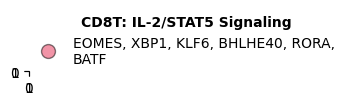

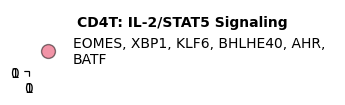

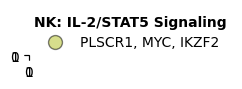

In [40]:
# - the term with bifurcation enrichment
term = 'IL-2/STAT5 Signaling'
cell_type = 'CD8T'

from ciim.src.tf_activity.plots import plot_term_genes
for cell_type in ['CD8T', 'CD4T', 'NK']:
    plot_term_genes(pathway_scores, cell_type, term)

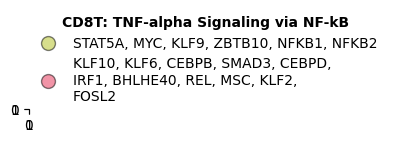

In [38]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'CD8T'

from ciim.src.tf_activity.plots import plot_term_genes

plot_term_genes(pathway_scores, cell_type, term)


In [31]:
from ciim.src.utils.util import get_genesets
pathways = get_genesets()
for key in pathways.keys():
    if 'STAT5' in key:
        print(key)
len(pathways['HALLMARK_IL2_STAT5_SIGNALING'])

HALLMARK_IL2_STAT5_SIGNALING


199

In [32]:
features = pathway_scores_all[(pathway_scores_all['Term']==term) & (pathway_scores_all['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()


True


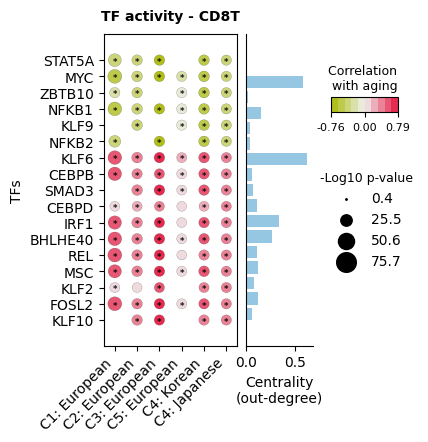

In [33]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


# Minor cell types

## Heatmap

In [34]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
race='both'
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)

    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add sig flags
    stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)

    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [35]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

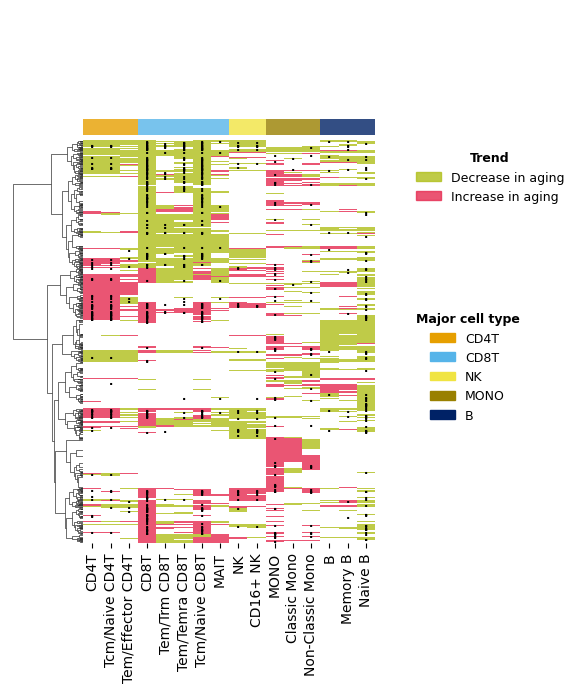

In [36]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, slope_col='slope', palette=palette_trend_2, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

## Pathways

In [37]:
type = 'bulk_minor'
race = 'both'
stats_sig = retrieve_sig_stats(type=type, race=race)

pathway_scores = pathway_analysis_wrapper(stats_sig)

(6, 10)
(3, 10)
(4, 10)
(3, 10)


(2, 10)
(2, 10)
(1, 10)
(4, 10)
(9, 10)
(5, 10)
(7, 10)
(5, 10)


In [38]:
ordered_minors = ['Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',
                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'Memory_B',
                    'Naive_B',]
ordered_minors = [item.replace('_', ' ') for item in ordered_minors]
pathway_scores['cell_type_pretty'] = pathway_scores['cell_type'].str.replace('_', ' ')
pathway_scores['cell_type_pretty'] = pd.Categorical(pathway_scores['cell_type_pretty'], categories=ordered_minors, ordered=True)
pathway_scores = pathway_scores[~pathway_scores['cell_type_pretty'].isna()]


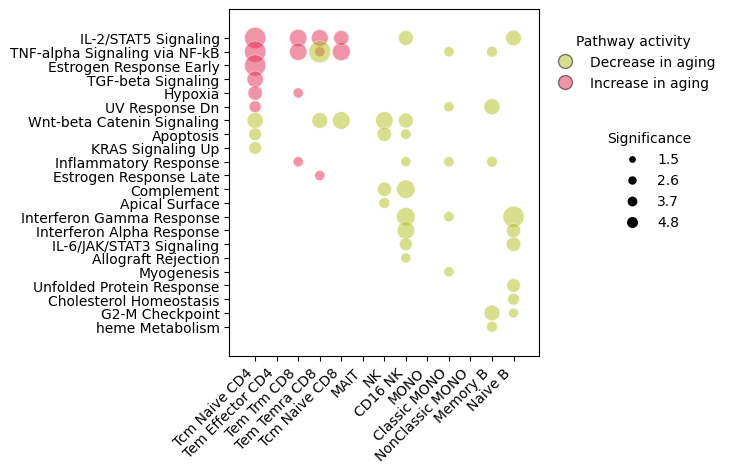

In [39]:
pathway_scores['neg_log10_adj_pval'] = -np.log10(pathway_scores["FDR"])
fig, ax = plt.subplots(1, 1, figsize=(4, 4.5))    

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type_pretty', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
ax.margins(x=.1, y=.1)
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [40]:
pathway_scores['Term'].unique()

array(['IL-2/STAT5 Signaling', 'TNF-alpha Signaling via NF-kB',
       'Estrogen Response Early', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis',
       'KRAS Signaling Up', 'Inflammatory Response',
       'Estrogen Response Late', 'Complement', 'Apical Surface',
       'Interferon Gamma Response', 'Interferon Alpha Response',
       'IL-6/JAK/STAT3 Signaling', 'Allograft Rejection', 'Myogenesis',
       'Unfolded Protein Response', 'Cholesterol Homeostasis',
       'G2-M Checkpoint', 'heme Metabolism'], dtype=object)

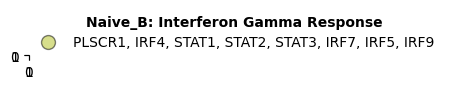

In [41]:
from ciim.src.tf_activity.plots import plot_term_genes
term= 'Interferon Gamma Response' #'TNF-alpha Signaling via NF-kB' 
plot_term_genes(pathway_scores, cell_type='Naive_B', term=term)
# plot_term_genes(pathway_scores, cell_type='Tcm_Naive_CD8', term=term)

No data for Tcm_Naive_CD8 source


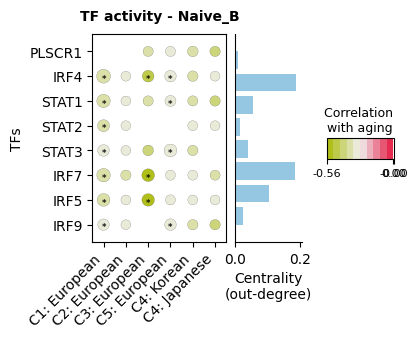

In [42]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
for cell_type in ['Naive_B', 'Tcm_Naive_CD8']:
    features = pathway_scores[(pathway_scores['Term']==term) & (pathway_scores['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()

    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                    feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


## Interaction of subtypes

['Tcm/Naive CD8T', 'Tem/Temra CD8T', 'Tem/Trm CD8T']


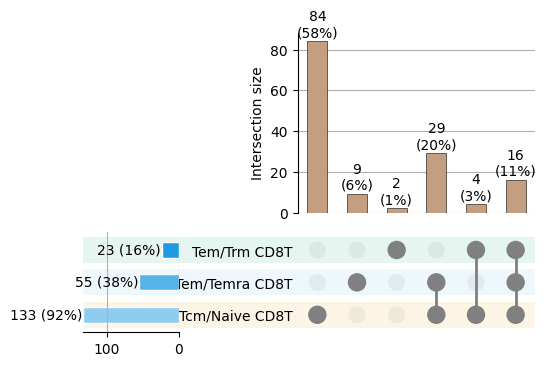

In [43]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
from ciim.src.common import palette_minor_types_pretty
type = 'bulk_minor'
race = 'both'

minor_types = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8',]

stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig = stats_sig[stats_sig['cell_type'].isin(minor_types)]
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

interaction_main_df_c = interaction_main_df.copy()
interaction_main_df_c.columns = interaction_main_df_c.columns.map(surrogate_names)
aa = plot_interactions(interaction_main_df_c, min_subset_size=2, color_map=palette_minor_types_pretty)

True
True
True


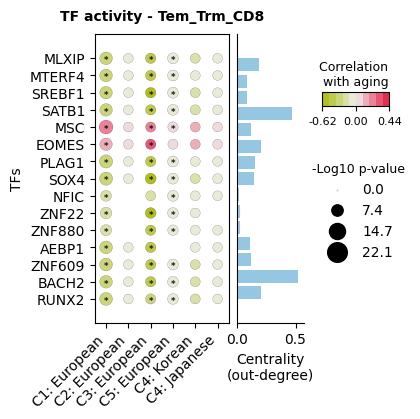

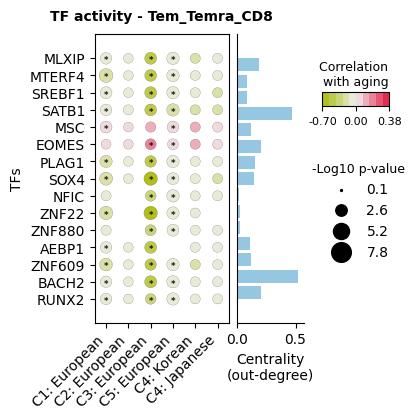

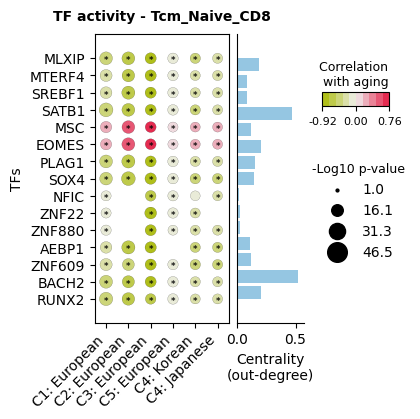

In [44]:
# - shared features
from ciim.src.tf_activity.plots import plot_features_vs_datasets
# - plot the common ones
features = interaction_main_df_c[interaction_main_df_c.sum(axis=1)==3].index
for cell_type in minor_types:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)


(20,)


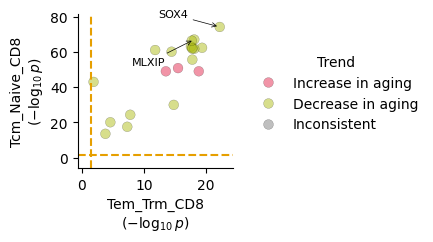

In [45]:
from ciim.src.tf_activity.plots import plot_joint_scatter

vars = ['Tem_Trm_CD8',
                'Tcm_Naive_CD8']
interaction_main_ts_df = interaction_main_df[vars]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=vars, annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

True


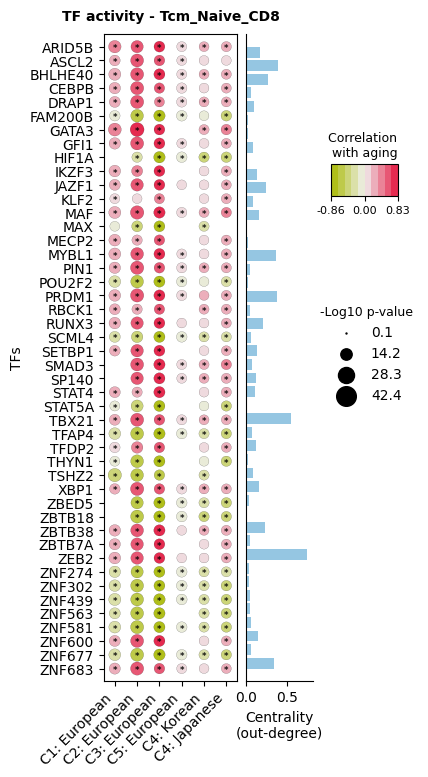

In [46]:
# - unique to one minor cell type
cell_type = 'Tcm_Naive_CD8'
unique_interactions = interaction_main_df[interaction_main_df.sum(axis=1)==1]
features = unique_interactions[unique_interactions[cell_type]].index
features = np.sort(features)
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True, margins={'x': 0.1, 'y': 0.02})

# Gender


## Overall plot

In [47]:
# - get the stats for bulk of both gender
from ciim.src.tf_activity.helper import retrieve_stats_features
from ciim.src.common import minor_cell_types, palette_minor_types


race='both'
data_type = 'bulk'

stats_store = []
for type in [data_type, f'{data_type}_M', f'{data_type}_F']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)
    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add valid cases
    stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)
        
    stats_tf['type'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'type', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'type', 'is_significant'])

stats_all_combined['gender'] = stats_all_combined['type'].map({data_type: 'Both', f'{data_type}_F': 'Female', f'{data_type}_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))

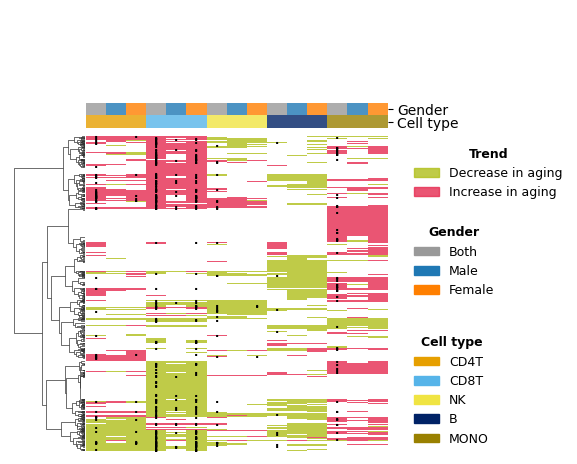

In [48]:
# - plot
from ciim.src.tf_activity.plots import plot_overall_heatmap

if data_type == 'bulk_minor':
    palette = palette_minor_types
    stats_all_combined = stats_all_combined[stats_all_combined['cell_type'].isin(minor_cell_types)]
    stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=minor_cell_types, ordered=True))
elif data_type == 'bulk':
    palette = palette_cell_types
    stats_all_combined = stats_all_combined[stats_all_combined['cell_type'].isin(cell_types)]
    stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

else:
    raise ValueError(f'Unknown data type {data_type}')

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(6, 8) if data_type == 'bulk_minor' else (5, 6),
                    bbox_to_anchor=(1.05, 1),
                    bbox_to_anchor_col1=(1.05, .6) if data_type == 'bulk_minor' else (1.05, .4),
                    bbox_to_anchor_col2=(1.05, .8) if data_type == 'bulk_minor' else (1.05, .75),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

## Interactions

In [49]:
race = 'both'
cell_type = 'Tcm_Naive_CD8' if data_type == 'bulk_minor' else 'CD8T'
# cell_type = 'MONO'

stats_sig_M  = retrieve_sig_stats(type=f'{data_type}_M', race=race)
stats_sig_M['gender'] = 'Male'
stats_sig_F = retrieve_sig_stats(type=f'{data_type}_F', race=race)
stats_sig_F['gender'] = 'Female'
stats_sig_all = pd.concat([stats_sig_M, stats_sig_F])


# - find tfs sig in one gender and not the other
features_dict = {}
for cell_type in [cell_type]:
    stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]  
    stats_M = stats_t[stats_t['gender']=='Male']
    stats_F = stats_t[stats_t['gender']=='Female']

    # - get the tfs
    sig_tfs_M = stats_M['tf'].unique()
    sig_tfs_F = stats_F['tf'].unique()

    # - only in M
    only_M = np.setdiff1d(sig_tfs_M, sig_tfs_F)
    only_F = np.setdiff1d(sig_tfs_F, sig_tfs_M)

    if True: # further filter the list to only those given in data1
        stats_M_diff = stats_M[stats_M['tf'].isin(only_M)]
        only_M = stats_M_diff[stats_M_diff['dataset']=='data1']['tf'].unique()

        stats_F_diff = stats_F[stats_F['tf'].isin(only_F)]
        only_F = stats_F_diff[stats_F_diff['dataset']=='data1']['tf'].unique()
    diff_tfs = np.union1d(only_M, only_F)
    features_dict[cell_type] = diff_tfs

print('tfs sig in one and not the other: ', features_dict)

tfs sig in one and not the other:  {'CD8T': array(['CREM', 'ELF1', 'FOS', 'IKZF2', 'IRF1', 'IRF9', 'JUNB', 'KLF2',
       'KLF3', 'MAFF', 'MAX', 'PA2G4', 'REL', 'STAT1', 'ZNF331'],
      dtype=object)}


True
Only 2 datasets are available in the stats.
True


Text(0.5, 1.1, 'Male')

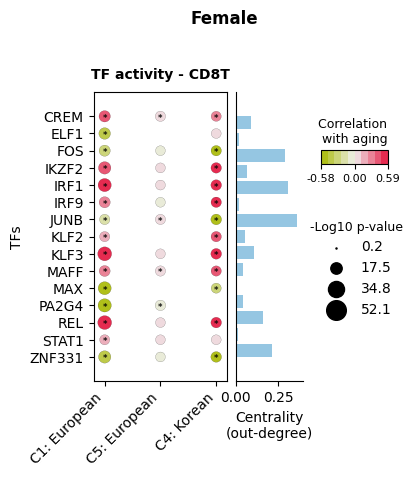

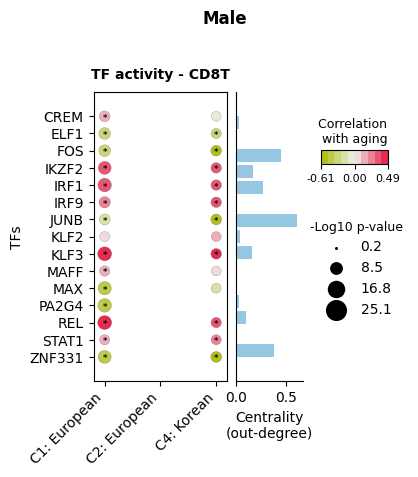

In [50]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

features = features_dict[cell_type]
datasets = ['data1', 'SLE_European', 'data13_Korean']
plot_features_vs_datasets(cell_type=cell_type, type=f'{data_type}_F', datasets=datasets, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Female', fontsize=12, y=1.1, fontweight='bold')
datasets = ['data1', 'data7_allTPs_jalil', 'data13_Korean']
plot_features_vs_datasets(cell_type=cell_type, type=f'{data_type}_M', datasets=datasets, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Male', fontsize=12, y=1.1, fontweight='bold')

# Disease

In [8]:
from ciim.src.tf_activity.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
type = 'bulk'
test_type= 'unpaired' #'mixed-effect'
dataset = 'SLE_European' #'SLE_European' Covid_50MHH
feature_type= 'tf_activity' #'tf_activity' gene_expression

disease_name = dataset.split('_')[0]
if True:
    os.makedirs(f'{save_dir}/stats', exist_ok=True)
    par = {
        'feature_type':feature_type, 
        'datasets': [dataset],
        'type': type,
        'cell_type_resolution': 'Major_CT',
        'association_type': 'spearman'
    }
    if feature_type == 'tf_activity':
        wrapper_tf_activity(par)
    else:
        wrapper_gene_expression(par)
    stats_disease = wrapper_association_with_age_condition(par, features=None, test_type=test_type)
    stats_disease.to_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
else:
    stats_disease = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')

Loading data...
Calculating TF activity...


cell types: 100%|██████████| 5/5 [00:02<00:00,  1.89it/s]


Association tf_activity with age/disease...


cell types: 100%|██████████| 5/5 [00:14<00:00,  2.98s/it]


## Overview

In [200]:
from ciim.src.common import mapping_minor_2_major
stats_disease = stats_disease[(~stats_disease['slope_condition'].isna())].copy()
stats_disease_sig = stats_disease[stats_disease['p_value_adj'] < 0.05].copy()
stats_disease_sig['major_cell_type'] = stats_disease_sig['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
stats_disease_sig.groupby(['cell_type'])['tf'].nunique()

cell_type
B        2
MONO    86
Name: tf, dtype: int64

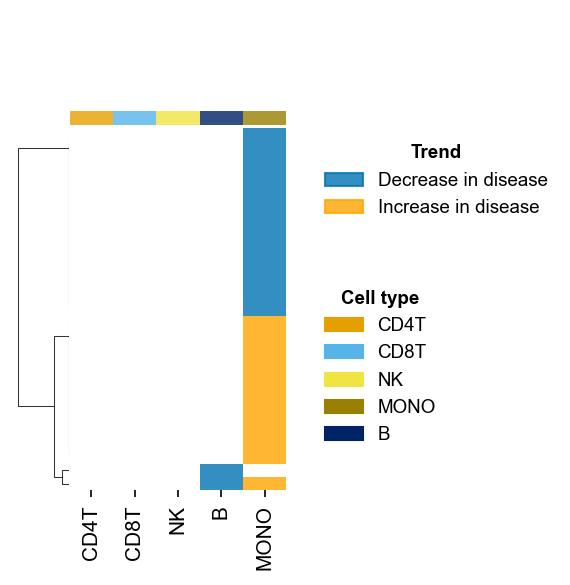

In [198]:
# - plot
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
from ciim.src.common import palette_disease_effect

if 'minor' in type:
    ordered_cell_names = [
                        'Tcm_Naive_CD4',
                        'Tem_Effector_CD4',
                        
                        'Tcm_Naive_CD8',
                        'Tem_Trm_CD8',
                        'Tem_Temra_CD8',
                        'MAIT',

                        'NK',
                        'CD16_NK',

                        'Classic_MONO',
                        'NonClassic_MONO',
                        
                        'Naive_B',
                        'Memory_B',
                        ]
    stats_disease_sig = stats_disease_sig[stats_disease_sig['cell_type'].isin(ordered_cell_names)]
    stats_disease_sig['cell_type'] = pd.Categorical(stats_disease_sig['cell_type'], categories=ordered_cell_names, ordered=True)
    stats_disease_sig['major_cell_type'] = stats_disease_sig['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

    stats_disease_sig_all = stats_disease_sig[stats_disease_sig['age_group']=='all']
    heamap_plot_minor_cell_types(stats_disease_sig_all, slope_col='slope_condition', palette=palette_disease_effect, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})
else:
    stats_disease_sig['cell_type'] = pd.Categorical(stats_disease_sig['cell_type'], categories=cell_types, ordered=True)
    stats_disease_sig['major_cell_type'] = stats_disease_sig['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

    stats_disease_sig_all = stats_disease_sig[stats_disease_sig['age_group']=='all']
    heamap_plot_minor_cell_types(stats_disease_sig_all, slope_col='slope_condition', palette=palette_disease_effect, figsize=(3, 4), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Cell type'})


## Aging TFs and disease

In [132]:
from ciim.src.common import palette_trend, palette_disease_effect

type = 'bulk'
aging_stats_sig = retrieve_sig_stats(type, race='both').drop_duplicates(subset=['cell_type', 'tf'])
aging_stats_sig = aging_stats_sig[['tf', 'cell_type', 'slope']]


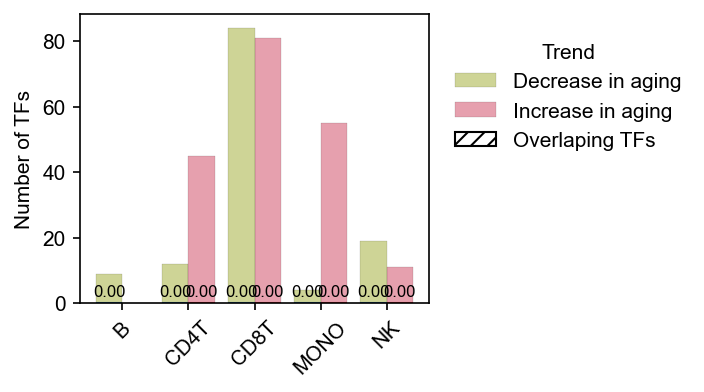

In [133]:
import pandas as pd
import numpy as np

def wrapper_disease_aging_overlap(stats_disease_sig, aging_stats_sig, age_group='all'):
    # Merge on tf and cell_type
    stats_disease_sig_age_group = stats_disease_sig[stats_disease_sig['age_group']==age_group]
    stats_disease_sig_age_group = stats_disease_sig_age_group[['tf', 'cell_type', 'slope_condition']]

    merged = aging_stats_sig.merge(stats_disease_sig_age_group, on=['tf', 'cell_type'], how='left')
    # Compute sign of slopes
    merged['slope_sign'] = np.sign(merged['slope'])
    merged['slope_condition_sign'] = np.sign(merged['slope_condition'])
    merged = merged.drop_duplicates(subset=['tf', 'cell_type', 'slope_sign', 'slope_condition_sign'])


    # Assign trend from reference slope
    merged['trend'] = merged['slope_sign'].map({1: 'positive', -1: 'negative'})

    # Now filter for agreement within each trend group
    def compute_agreement(group):
        total = len(group)
        agree = (group['slope_sign'] == group['slope_condition_sign']).sum()
        return pd.Series({'n_total_tfs': total, 'n_agreeing_tfs': agree})

    summary = (
        merged.groupby(['cell_type', 'trend'])
        .apply(compute_agreement)
        .reset_index()
    )

    summary['fraction_agree'] = summary['n_agreeing_tfs'] / summary['n_total_tfs']
    summary['trend'] = ['Increase in aging' if x == 'positive' else 'Decrease in aging' for x in summary['trend']]

    ## - plot
    import matplotlib.patches as mpatches

    plt.figure(figsize=(3, 2.5))
    # sns.set(style="whitegrid")
    df = summary.copy()

    # Plot total TFs as filled bars
    ax = sns.barplot(data=df, x='cell_type', y='n_total_tfs', hue='trend',
                    dodge=True, alpha=0.5, palette=palette_trend_2, edgecolor='black', linewidth=.1)

    # Overlay agreeing TFs as hatched bars
    cell_types = df['cell_type'].unique()
    offset = {'Decrease in aging': -0.2, 'Increase in aging': 0.2}
    colors = {'Decrease in aging': 'tab:blue', 'Increase in aging': 'tab:red'}

    for i, row in df.iterrows():
        xpos = list(cell_types).index(row['cell_type']) + offset[row['trend']]
        ax.bar(
            xpos, row['n_agreeing_tfs'],
            width=0.4, edgecolor=colors[row['trend']], facecolor='none',
            hatch='///', linewidth=1, zorder=1
        )
        ax.text(
            xpos, row['n_agreeing_tfs'] + 1,
            f"{row['fraction_agree']:.2f}",
            ha='center', va='bottom', fontsize=8
        )

    plt.xticks(rotation=45, ha='center')
    plt.grid(axis='y', linestyle='--', alpha=0)
    plt.ylabel("Number of TFs")
    plt.xlabel("")

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    hatch_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Agreeing TFs (overlap)')
    handles.append(hatch_patch)
    labels.append('Overlaping TFs')
    ax.legend(handles=handles, labels=labels, title='Trend', loc=(1.05, .5), frameon=False)

age_group='all'
wrapper_disease_aging_overlap(stats_disease_sig, aging_stats_sig, age_group=age_group)

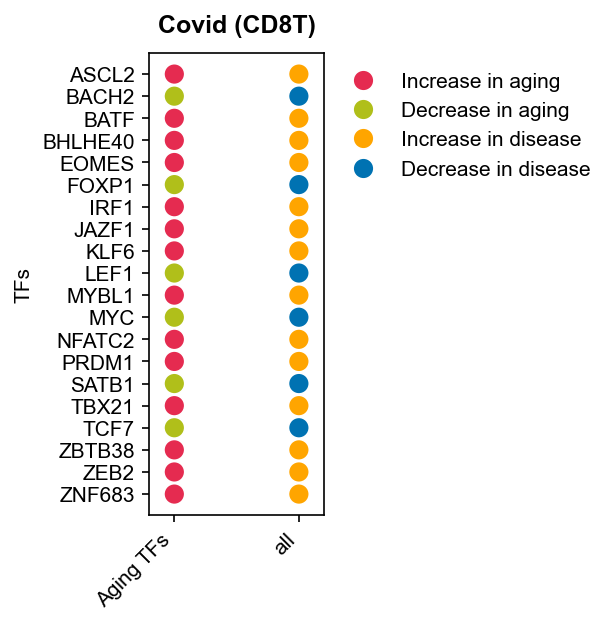

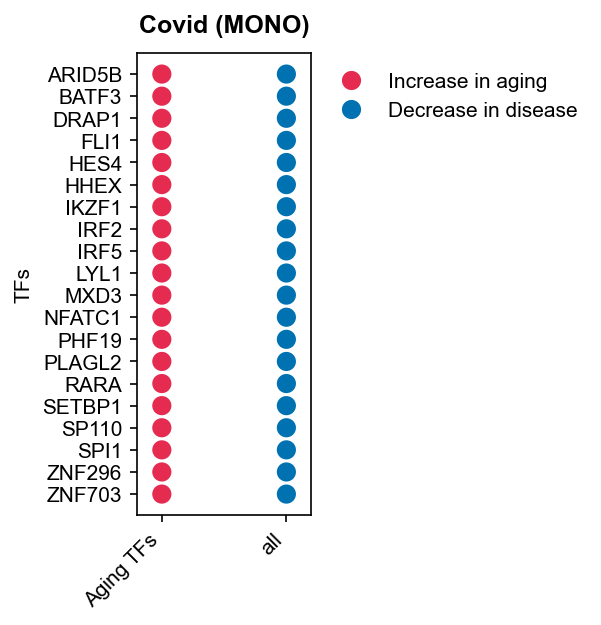

In [134]:

top_aging_tfs = 20
age_groups = stats_disease['age_group'].unique()


palette_all = {**palette_trend, **palette_disease_effect}
stats_disease['dataset'] = stats_disease['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in ['CD8T', 'MONO']:
    # --- Aging TFs ---
    aging_df = aging_stats_sig[aging_stats_sig['cell_type'] == cell_type]
    net = get_consensus_net(datasets_all, cell_type, min_degree=3)
    c_df = net.groupby('source').size().reset_index(name='degree')
    aging_df = aging_df.merge(c_df, left_on='tf', right_on='source', how='left')[['tf', 'slope', 'degree']]
    aging_df['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in aging_df['slope']]
    aging_df['analysis'] = 'Aging TFs'

    # --- Disease TFs ---
    stats_store = []
    for age_group in stats_disease['age_group'].unique():
        stats_d = stats_disease[
            (stats_disease['age_group'] == age_group) &
            (stats_disease['cell_type'] == cell_type) &
            (~stats_disease['slope_condition'].isna())
        ].copy()
        stats_d = stats_d[['tf', 'cell_type', 'slope_condition', 'p_value_adj']].drop_duplicates()
        stats_d['analysis'] = age_group
        stats_d['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d['slope_condition']]
        stats_store.append(stats_d)

    stats_a = pd.concat(stats_store)
    stats_a['analysis'] = stats_a['analysis'].astype(pd.CategoricalDtype(categories=age_groups, ordered=True))

    # --- Restrict to TFs in both aging and disease before top-N ---
    common_tfs = set(aging_df['tf']) & set(stats_a['tf'])
    aging_df = aging_df[aging_df['tf'].isin(common_tfs)]

    top_tfs = aging_df.sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique()

    # --- Combine and filter ---
    stats_combined = pd.concat([aging_df, stats_a])
    df = stats_combined[stats_combined['tf'].isin(top_tfs)]

    # --- Plot ---
    fig, ax = plt.subplots(1, 1, figsize=(1.5, len(top_tfs) * 0.2))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, s=100)

    # Overlay black stars for significant TFs
    sig_df = df[df.get('p_value_adj', 1.0) < 0.05]
    ax.scatter(sig_df['analysis'], sig_df['tf'], color='black', marker='*', s=20, zorder=10)

    # Handle missing x-axis categories
    missing = set(age_groups) - set(df['analysis'].unique())
    for cat in missing:
        ax.scatter(cat, df['tf'].iloc[0], color='white', alpha=0)

    ax.margins(x=.2, y=.05 if len(top_tfs) > 10 else 0.2)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.title(f'{disease_name} ({cell_type})', pad=10, weight='bold')
    plt.savefig(f'{plots_dir}/aging_{disease_name}_overlap_{cell_type}.png', bbox_inches='tight', dpi=300)

Text(0.5, 1.4, 'CD8T (ZEB2)')

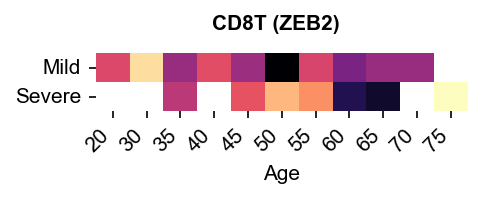

In [128]:
from ciim.src.tf_activity.plots import heatplot_age_trend
from collections import defaultdict
from ciim.src.common import surrogate_names


def format_tf_activity_for_disease_trend_plot(dataset, type, cell_type, tf, age_limit=[20, 75], condition_col='disease'):
    tf_acts = retrieve_feature_data(dataset, cell_type, type=type)
    tf_acts = tf_acts[(tf_acts.obs['age'] >= age_limit[0]) & (tf_acts.obs['age'] <= age_limit[1])]
    tf_acts = tf_acts[:, tf_acts.var_names == tf]
    if tf_acts.shape[1]==0:
        return None

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', condition_col]], left_index=True, right_index=True, how='left')
    expr[condition_col] = expr[condition_col].astype('category')
    expr['age'] = expr['age'].astype(int)

    # Pivot table: rows = disease, columns = age, values = expression
    expr_table = expr.pivot_table(index=condition_col, columns='age', values=tf)

    # Bin ages into 5-year intervals
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = defaultdict(list)

    for col in age_columns:
        bin_start = (col // 5) * 5
        age_bins[bin_start].append(col)

    # Average across bins
    binned_means = {bin_start: df[bin_ages].mean(axis=1) for bin_start, bin_ages in age_bins.items()}
    binned_df = pd.DataFrame(binned_means)

    # Sort bins by age
    binned_df = binned_df[sorted(binned_df.columns)]
    
    return binned_df

def plot_healthy_disease_trend(dataset, type, cell_type, case_tf, condition_col):
    binned_df = format_tf_activity_for_disease_trend_plot(dataset, type, cell_type, tf=case_tf, condition_col=condition_col)
    binned_df.index = [surrogate_names.get(name, name) for name in binned_df.index]
    fig, ax = plt.subplots(1, 1, figsize=(3.2, .5), sharey=False, sharex=True)
    heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF \n activity", y_label="Condition", ax=ax, show_cbar=False, shrink=1)
    ax.set_xlabel('Age')
    
case_tf = 'ZEB2'
cell_type = 'CD8T'
dataset = 'Covid_50MHH' #'SLE_European' Covid_50MHH
condition_col = 'disease' if dataset=='SLE_European' else 'Max_WHO_Group'
plot_healthy_disease_trend(dataset=dataset, type='bulk', cell_type=cell_type, case_tf=case_tf, condition_col=condition_col)
plt.suptitle(f'{surrogate_names.get(cell_type, cell_type)} ({case_tf})', fontsize=10, fontweight='bold', y=1.4)

# case_tf = 'ZEB2'
# cell_type = 'Tcm_Naive_CD8'
# plot_healthy_disease_trend(dataset='SLE_European', type='bulk', cell_type=cell_type, case_tf=case_tf)    
# plt.suptitle(f'{surrogate_names[cell_type]} ({case_tf})', fontsize=10, fontweight='bold', y=1.4)

# Drug perturbation

In [9]:
from ciim.src.tf_activity.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
type = 'bulk'
test_type= 'paired' #'mixed-effect'
dataset = 'CXCL9'
feature_type= 'tf_activity' #'tf_activity' gene_expression

if True:
    os.makedirs(f'{save_dir}/stats', exist_ok=True)
    par = {
        'feature_type':feature_type, 
        'datasets': [dataset],
        'type':type,
        'cell_type_resolution': 'Major_CT',
    }
    if feature_type == 'tf_activity':
        wrapper_tf_activity(par)
    else:
        wrapper_gene_expression(par)

    stats_all = wrapper_association_with_age_condition(par, features=None, test_type=test_type)
    stats_all.to_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
else:
    stats_all = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')

Loading data...
Calculating TF activity...


cell types: 100%|██████████| 5/5 [00:07<00:00,  1.49s/it]


Association tf_activity with age/disease...


cell types: 100%|██████████| 5/5 [01:11<00:00, 14.26s/it]


## Overview

In [11]:
from collections import OrderedDict

comparision_names = OrderedDict(
    {
        '24 h LPS': 'LPS/RPMI',
        '24 h RPMI + metformin': 'Metformin (ctr: RPMI)',
        '24 h RPMI + ruxolitinib': 'Ruxolitinib (ctr: RPMI)',

        '24 h LPS + metformin': 'Metformin (ctr: LPS)',
        '24 h LPS + ruxolitinib': 'Ruxolitinib (ctr: LPS)',
    }
)

In [12]:
# - stats of RMPI and LPs as controls
stats_store = []
stats = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h LPS', '24 h RPMI + metformin', '24 h RPMI + ruxolitinib']))] 
stats_store.append(stats)

stats = stats_all[(stats_all['ctrl']=='24 h LPS') & (stats_all['condition'].isin(['24 h LPS + metformin', '24 h LPS + ruxolitinib']))] 

stats_store.append(stats)


stats_drugs = pd.concat(stats_store, axis=0)
stats_drugs['comparision'] = stats_drugs['condition'].replace(comparision_names)
stats_drugs = stats_drugs[~stats_drugs['comparision'].isna()]
stats_drugs.drop(columns=['condition'], inplace=True)

stats_drugs['comparision'] = stats_drugs['comparision'].astype('category')
stats_drugs['cell_type'] = pd.Categorical(stats_drugs['cell_type'], categories=cell_types, ordered=True)


stats_drugs['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_drugs['slope_condition']]
ctrls = stats_drugs['ctrl'].unique()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

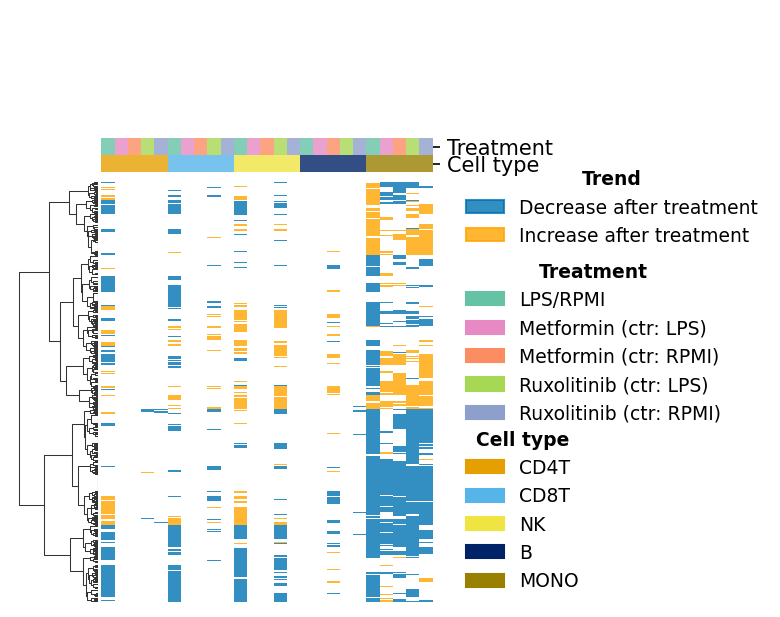

In [13]:
from ciim.src.tf_activity.plots import plot_overall_heatmap
from ciim.src.common import palette_treatment, palette_cell_types

stats_all_c = stats_drugs.copy()
stats_all_c = stats_all_c.rename(columns={'slope_condition': 'slope'})
stats_all_c = stats_all_c[stats_all_c['p_value_adj'] < 0.05]

stats_all_c.rename(columns={'target': 'tf'}, inplace=True)
plot_overall_heatmap(stats_all_c, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  
                    first_col_palette=palette_cell_types,
                    second_col='comparision', 
                    second_col_palette={value: color for value, color in zip(comparision_names.values(), sns.color_palette("Set2", n_colors=len(comparision_names.values())) )},
                    trend_colors = list(palette_treatment.values()),
                    trend_names = list(palette_treatment.keys()),
                    bbox_to_anchor=(1.05, 1.07),
                    bbox_to_anchor_col1=(1.05, .45),
                    bbox_to_anchor_col2=(1.05, .85),
                    figsize=(4, 6.5),
                    map_names={**{'cell_type':'Cell type', 'comparision': 'Treatment'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Aging TFs

In [14]:
stats_drugs_sig  = stats_drugs[stats_drugs['p_value_adj'] < 0.05]

In [ ]:
# merged.groupby('comparision').size()

comparision
LPS/RPMI                   63
Metformin (ctr: LPS)        0
Metformin (ctr: RPMI)       0
Ruxolitinib (ctr: LPS)     28
Ruxolitinib (ctr: RPMI)     1
dtype: int64

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

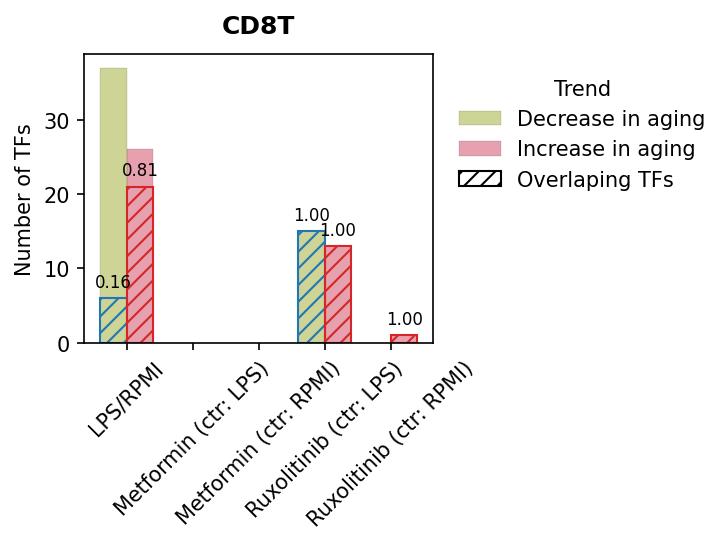

In [29]:
import pandas as pd
import numpy as np

def wrapper_drug_aging_overlap(
        stats_drug_sig_all, 
        aging_stats_sig_all, 
        cell_type='MONO', 
        agreement='opposite' # the tretment effect should be 'opposite' to the aging effect
        ):
    # Merge on tf and cell_type
    stats_drug_sig_all = stats_drug_sig_all[['tf', 'cell_type', 'slope_condition', 'comparision']]
    stats_drug_sig = stats_drug_sig_all[stats_drug_sig_all['cell_type'] == cell_type].copy()
    aging_stats_sig = aging_stats_sig_all[aging_stats_sig_all['cell_type'] == cell_type].copy()

    merged = aging_stats_sig.merge(stats_drug_sig, on=['tf', 'cell_type'], how='left')
    
    # Compute sign of slopes
    merged['slope_sign'] = np.sign(merged['slope'])
    merged['slope_condition_sign'] = np.sign(merged['slope_condition'])
    merged = merged.drop_duplicates(subset=['tf', 'cell_type', 'slope_sign', 'slope_condition_sign', 'comparision'])

    # Assign trend from reference slope
    merged['trend'] = merged['slope_sign'].map({1: 'positive', -1: 'negative'})

    # Now filter for agreement within each trend group
    def compute_agreement(group):
        total = len(group)
        if agreement == 'opposite':
            agree = (group['slope_sign'] != group['slope_condition_sign']).sum()
        else:
            agree = (group['slope_sign'] == group['slope_condition_sign']).sum()
        return pd.Series({'n_total_tfs': total, 'n_agreeing_tfs': agree})

    summary = (
        merged.groupby(['comparision', 'trend'])
        .apply(compute_agreement)
        .reset_index()
    )

    summary['fraction_agree'] = summary['n_agreeing_tfs'] / summary['n_total_tfs']
    summary['trend'] = ['Increase in aging' if x == 'positive' else 'Decrease in aging' for x in summary['trend']]
    ## - plot
    import matplotlib.patches as mpatches    
    plt.figure(figsize=(3, 2.5))
    df = summary.copy()
    # df['comparision'] = df['comparision'].astype(pd)
    ax = sns.barplot(data=df, x='comparision', y='n_total_tfs', hue='trend',
                    dodge=True, alpha=0.5, palette=palette_trend_2, edgecolor='black', linewidth=.1)

    # Overlay agreeing TFs as hatched bars
    comparisions = df['comparision'].unique()
    offset = {'Decrease in aging': -0.2, 'Increase in aging': 0.2}
    colors = {'Decrease in aging': 'tab:blue', 'Increase in aging': 'tab:red'}

    for i, row in df.iterrows():
        xpos = list(comparisions).index(row['comparision']) + offset[row['trend']]
        ax.bar(
            xpos, row['n_agreeing_tfs'],
            width=0.4, edgecolor=colors[row['trend']], facecolor='none',
            hatch='///', linewidth=1, zorder=1
        )
        ax.text(
            xpos, row['n_agreeing_tfs'] + 1,
            f"{row['fraction_agree']:.2f}",
            ha='center', va='bottom', fontsize=8
        )

    plt.xticks(rotation=45, ha='center')
    plt.grid(axis='y', linestyle='--', alpha=0)
    plt.ylabel("Number of TFs")
    plt.xlabel("")

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    hatch_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Agreeing TFs (overlap)')
    handles.append(hatch_patch)
    labels.append('Overlaping TFs')
    ax.legend(handles=handles, labels=labels, title='Trend', loc=(1.05, .5), frameon=False)
    ax.set_title(f'{cell_type}', fontsize=12, fontweight='bold', pad=10)
aging_stats_sig = retrieve_sig_stats(type, race='both').drop_duplicates(subset=['cell_type', 'tf'])
aging_stats_sig = aging_stats_sig[['tf', 'cell_type', 'slope']]
merged = wrapper_drug_aging_overlap(stats_drugs_sig, aging_stats_sig, cell_type='CD8T')
# wrapper_drug_aging_overlap(stats_drugs_sig, aging_stats_sig, cell_type='MONO')
# wrapper_drug_aging_overlap(stats_drugs_sig, aging_stats_sig, cell_type='NK')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

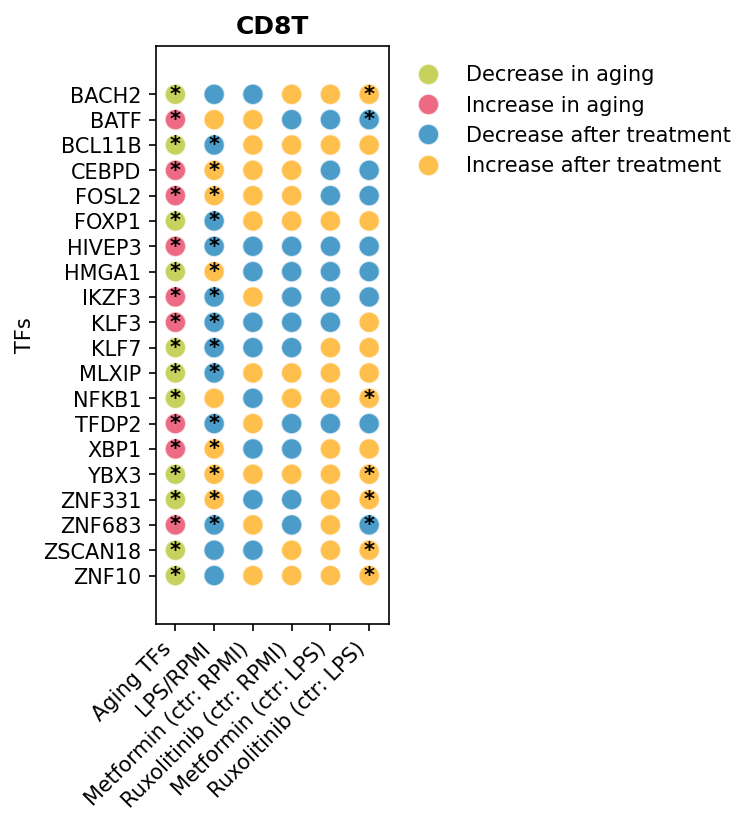

In [31]:
from ciim.src.common import palette_trend, palette_treatment
palette_all = {**palette_trend, **palette_treatment}
# stats_RPMI_ctr['dataset'] = stats_RPMI_ctr['dataset'].apply(lambda name: surrogate_names.get(name, name))
stats_df = stats_drugs.copy()

type = 'bulk'
race = 'both'
top_aging_tfs = 20

os.makedirs(f'{save_dir}/plots', exist_ok=True)

for cell_type in ['CD8T']:
    # - aging tfs
    stats_aging  = retrieve_sig_stats(type=type, race=race).drop_duplicates(subset=['tf', 'cell_type'])
    stats_aging = stats_aging[stats_aging['cell_type']==cell_type]
    stats_aging['analysis'] = 'Aging TFs'

    # - drugs
    stats_sotre = []
    for d in stats_df['comparision'].unique():
        stats_d = stats_df[(stats_df['comparision'] == d) & (stats_df['cell_type'] == cell_type)].copy()
        stats_d['is_significant'] = stats_d['p_value_adj'] < 0.05

        stats_d['analysis'] = d 
        stats_d['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_d = pd.concat(stats_sotre)
    # - subset the aging tfs to the drugs
    stats_d_sig = stats_d[stats_d['p_value_adj'] < 0.05]
    drug_tfs = stats_d_sig['tf'].unique()
    agings_tfs = stats_aging['tf'].unique()
    common_tfs = np.intersect1d(drug_tfs, agings_tfs)

    # - merge
    df = pd.concat([stats_aging, stats_d])
    df = df[df['tf'].isin(common_tfs)]
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    # - subset the tfs
    if True:
        net = get_consensus_net(datasets_all, cell_type, min_degree=3)
        c_df = net.groupby('source').size().reset_index(name='degree')
        df_merged = df.merge(c_df, left_on='tf', right_on='source', how='left')

        top_tfs = df_merged.drop_duplicates(subset=['cell_type', 'tf']).sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique() # change this to centrality
        df = df[df['tf'].isin(top_tfs)]
    
    fig, ax = plt.subplots(1, 1, figsize=(2,len(top_tfs)*.2 + 1))
    # df['analysis'] = df['analysis'].apply(lambda name: pretty_names.get(name, name))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, 
                    s=100 , 
                    # sizes=(50, 100), 
                    alpha=.7)
    ax.margins(x=.1, y=.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Add significance annotation (e.g., a dot or asterisk) to significant points
    for _, row in df.iterrows():
        if row.get('is_significant', False):  # Ensure this column exists
            ax.text(
                x=row['analysis'],
                y=row['tf'],
                s='*',  # or '.' or '★'
                color='black',
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )
    plt.title(f'{cell_type}', fontsize=12, fontweight='bold')
    plt.savefig(f'{save_dir}/plots/aging_drug_trend_{cell_type}.png', bbox_inches='tight', dpi=300)

## Pathway analysis

In [112]:
from ciim.src.utils.util import pathway_analysis_wrapper
pathway_scores_store = []
for ctr in stats_drugs['ctrl'].unique():
    for treatment in stats_drugs['comparision'].unique():
        stats_sig = stats_drugs[(stats_drugs['ctrl'] == ctr) & (stats_drugs['comparision'] == treatment) & (stats_drugs['p_value_adj'] < 0.05)]
        if len(stats_sig) == 0:
            continue
        pathway_scores = pathway_analysis_wrapper(stats_sig, pvalue_col='p_value_adj', gene_sets=['KEGG_2021_Human']) #'MSigDB_Hallmark_2020'
        if pathway_scores is None:
            continue
        pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])
        pathway_scores['ctrl'] = ctr
        pathway_scores['comparision'] = treatment
        pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

(2, 10)
(2, 10)
(4, 10)
(35, 10)
(2, 10)
(17, 10)
(5, 10)
(1, 10)
(32, 10)
(13, 10)
(24, 10)
(7, 10)
(70, 10)
(9, 10)
(8, 10)


In [113]:
from ciim.src.tf_activity.plots import dotplot_category_color
from ciim.src.common import palette_treatment

def plot_pathways_enrichment(pathway_df, title=f'metformin'):
    tfs = pathway_df['Term'].unique()
    conditions = pathway_df['comparision'].unique()
    fig, axes = plt.subplots(1, len(conditions), figsize=(2*len(conditions), len(tfs)*.2+.5), sharey=True, sharex=True)

    for i, condition in enumerate(conditions):
        ax = axes[i] if len(conditions)>1 else axes
        pathway_scores = pathway_df[pathway_df['comparision']==condition]
        if len(pathway_scores) == 0:
            continue
        # pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
        if i == len(conditions)-1:
            show_color_legend = True
            show_size_legend = True
        else:
            show_color_legend = False
            show_size_legend = False
        dotplot_category_color(pathway_scores, 
                    ax, 
                    color_col='trend', 
                    size_col='neg_log10_adj_pval', 
                    x='cell_type', 
                    y='Term', 
                    sizes=(50, 250),
                    show_color_legend=show_color_legend, 
                    show_size_legend=show_size_legend,
                    size_legend_title='Significance',
                    color_legend_title='Pathway activity',
                    size_legend_loc=(1.2, 0.35),
                    color_legend_loc=(1.02, 0.75),
                    y_label='',
                    alpha=0.5,
                    palette=palette_treatment)
        ax.set_title(condition, fontsize=10, fontweight='bold', pad=12)

    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.05)
if False:
    pathway_scores_all['cell_type'] = pathway_scores_all['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))
    plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h RPMI'], title=f'RPMI')
    plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h LPS'], title=f'LPS')


In [114]:

# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'MONO'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[
        (pathway_scores['Term'] == term) &
        (pathway_scores['cell_type'] == cell_type)
    ]
    
    if pathway_scores_t.empty:
        print(f"No data found for cell type '{cell_type}' and term '{term}'")
        return

    df = (
        pathway_scores_t
        .groupby('trend')['Genes']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='Genes')
        .set_index('trend')
    )

    pp_dict = {}
    every_n_words = 5

    for trend in df.index:
        genes = df.loc[trend, 'Genes'].split(';')
        if trend == 'Increase in aging':
            wrapped = ', \n'.join(
                [', '.join(genes[i:i + every_n_words]) for i in range(0, len(genes), every_n_words)]
            )
        else:
            wrapped = ', '.join(genes)
        pp_dict[trend] = wrapped

    # Actual plot
    from matplotlib.lines import Line2D
    alpha = 0.5
    plt.figure(figsize=(0, 0))

    # Create legend handles only for present trends
    color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markersize=10, label=pp_dict[trend], alpha=alpha)
        for trend, color in palette_treatment.items()
        if trend in pp_dict
    ]

    legend = plt.legend(
        title=f'{cell_type}: {term}',
        title_fontsize=10,
        fontsize=10,
        handles=color_legend,
        loc=(1, .1),
        frameon=False
    )
    legend.get_title().set_fontweight('bold')
for ctr in ctrls:
    pathway_scores = pathway_scores_all[pathway_scores_all['ctrl']==ctr]
    explode_bifurcation_term(cell_type, term)



No data found for cell type 'MONO' and term 'TNF-alpha Signaling via NF-kB'
No data found for cell type 'MONO' and term 'TNF-alpha Signaling via NF-kB'


## Evaluate the known targets of drugs

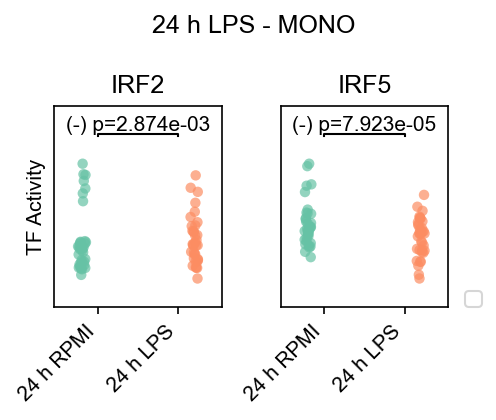

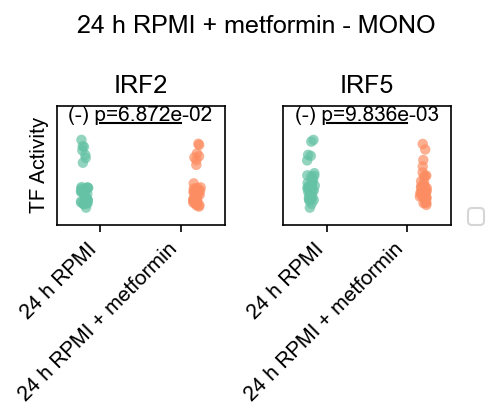

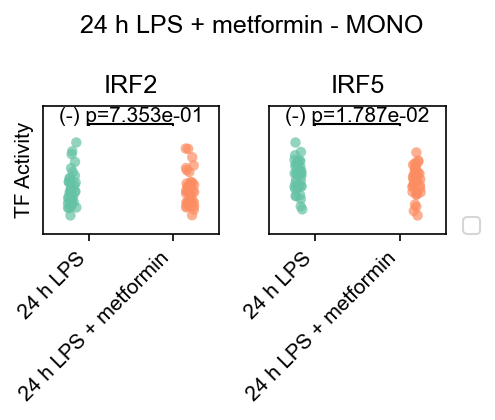

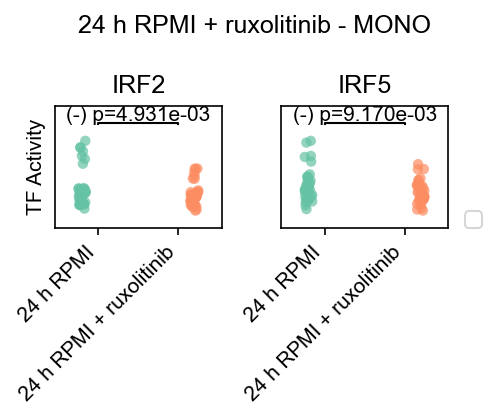

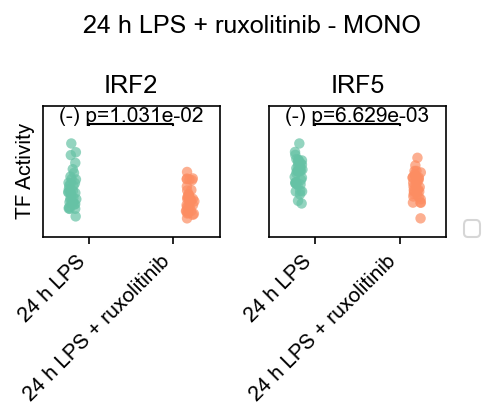

In [115]:
from ciim.src.tf_activity.plots import plot_ctr_condition_distribution

# features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
features = ['SPI1', 'DRAP1', 'ARID5B', 'IRF2', 'IRF5']

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h LPS', '24 h LPS + metformin'),

                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                ('24 h LPS', '24 h LPS + ruxolitinib')
                ]
for ctr, treatment in experiments:
    plot_ctr_condition_distribution(['MONO'], features, treatment, ctr, dataset, type=type, feature_type=feature_type, 
                                    map_names={}, 
                                    stats=stats_all.rename(columns={'tf':'gene', 'target':'gene'}))




In [116]:
# !ls /vol/projects/jnourisa/output//tf_activity/

# Trajectory plot: TF acitvity with age


In [117]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata_bulk(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{save_dir}/tf_activity/trends_{cell_type}_case.png', dpi=300)

OSError: Unable to synchronously open file (truncated file: eof = 114032640, sblock->base_addr = 0, stored_eof = 598405820)

## TF activity trend vs expression trend in aging


In [52]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, retrieve_adata_bulk

stats_store = []
for dataset in datasets:
    adata = retrieve_adata_bulk(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}/tf_activity/activation_vs_expression.png', dpi=300)

ImportError: cannot import name 'determine_stats' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)